# 

In [1]:
import os
from pathlib import Path
import json
import torch
import torch.nn as nn
from attention import self_attention
import matplotlib.pyplot as plt

TOKEN_TO_IDX = {"X": 0, "O": 1, "_": 2}
RESULT_TO_IDX = {"X": 1, "O": -1, "_": 0}  # for game result
cwd = Path().resolve().parent.parent

TRAINING_DATA_FILE_PATH = './data-generation-script/mcts_training_data.json'


In [6]:
def load_training_data(file_path):
    if not os.path.exists(file_path):
        raise ValueError("File does not exists")
    with open(file_path, "r") as f:
        data = json.load(f)

    for each in data:
        each["board_indices"] = torch.tensor(
            [TOKEN_TO_IDX[val] for val in each["board"]]
        )
        each["result_index"] = torch.tensor(RESULT_TO_IDX[each["result"]])
        each["move"] = torch.tensor(each["move"])
    return data


class TicTacToeTransformer(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.W_Q = nn.Parameter(torch.randn(3, 3))
        self.W_K = nn.Parameter(torch.randn(3, 3))
        self.W_V = nn.Parameter(torch.randn(3, 3))
        self.embeddings = nn.Embedding(3, 3)
        self.output_layer = nn.Linear(3, 1)

    def forward(self, x):
        x = self.embeddings(x)
        x = torch.stack(self_attention(x, self.W_Q, self.W_K, self.W_V))
        y = self.output_layer(x)
        y = y.squeeze(1)
        return y


training_data = load_training_data(TRAINING_DATA_FILE_PATH)

model = TicTacToeTransformer()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
criterion = torch.nn.CrossEntropyLoss()

In [7]:
split = int(0.8*len(training_data))
train_data = training_data[:split]
val_data = training_data[split:]

In [8]:
len(training_data)

6455

In [ ]:
losses = []

for epoch in range(10):
    epoch_loss = 0.0
    for data in train_data:
        x = data['board_indices']  # add batch dimension
        y = data['move']          # target as tensor

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()  # accumulate batch loss

    # These lines are **after the inner loop**, still inside epoch loop
    avg_loss = epoch_loss / len(train_data)
    losses.append(avg_loss)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in val_data:
            x = data['board_indices']
            y = data['move']
            logits = model(x)
            val_loss+=criterion(logits,y).item()
        avg_val_loss = val_loss/len(val_data)
        model.train()
            
            
    print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f} Validation loss:{avg_val_loss:.4f}")

Epoch 1 - Loss: 1.9031 Validation loss:1.7589
Epoch 2 - Loss: 1.7348 Validation loss:1.7478
Epoch 3 - Loss: 1.7317 Validation loss:1.7476
Epoch 4 - Loss: 1.7317 Validation loss:1.7476


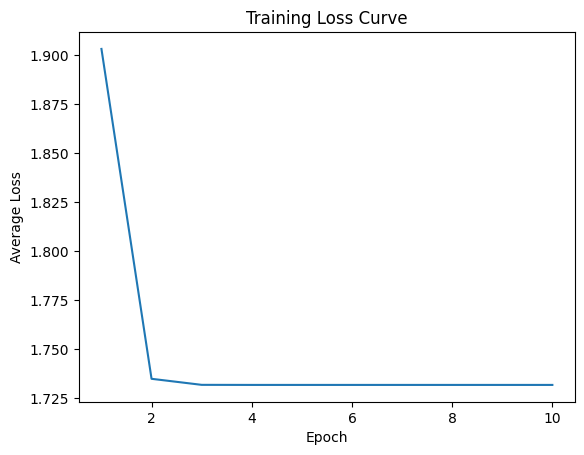

In [10]:
plt.plot(range(1, len(losses)+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve")
plt.show()

In [8]:
def predict_move(model, board):
    token_to_idx = {"X": 0, "O": 1, "_": 2}
    indices = torch.tensor([token_to_idx[s] for s in board])
    
    model.eval()
    with torch.no_grad():
        logits = model(indices)
    
    # mask illegal moves (non-empty cells)
    for i, cell in enumerate(board):
        if cell != "_":
            logits[i] = float('-inf')
    
    move = torch.argmax(logits).item()
    return move

In [9]:
# O about to win - model should block at position 2
board = ["O", "O", "_", "X", "X", "_", "_", "_", "_"]
print(predict_move(model, board))  # should return 2 or 5

# X about to win - model should play position 2
board = ["X", "X", "_", "O", "O", "_", "_", "_", "_"]
print(predict_move(model, board))  # should return 2

2
2


In [8]:
embeddings = torch.rand(9,3)

In [11]:
embeddings

tensor([[0.7498, 0.4814, 0.3397],
        [0.1460, 0.8880, 0.5689],
        [0.9831, 0.3938, 0.0678],
        [0.7104, 0.9878, 0.2654],
        [0.4309, 0.2432, 0.1839],
        [0.7692, 0.2401, 0.4711],
        [0.4251, 0.2307, 0.3040],
        [0.8481, 0.0769, 0.4804],
        [0.6271, 0.5469, 0.1956]])

In [12]:
even = embeddings[:,::2]

In [16]:
even

tensor([[0.7498, 0.3397],
        [0.1460, 0.5689],
        [0.9831, 0.0678],
        [0.7104, 0.2654],
        [0.4309, 0.1839],
        [0.7692, 0.4711],
        [0.4251, 0.3040],
        [0.8481, 0.4804],
        [0.6271, 0.1956]])

In [18]:
odd = embeddings[:,1::2]

In [19]:
odd

tensor([[0.4814],
        [0.8880],
        [0.3938],
        [0.9878],
        [0.2432],
        [0.2401],
        [0.2307],
        [0.0769],
        [0.5469]])

In [20]:
x = torch.rand(9,3)

In [40]:
x_shape = torch.arange(x.shape[0]).unsqueeze(1).expand_as(x)
x_shape

tensor([[0, 0, 0],
        [1, 1, 1],
        [2, 2, 2],
        [3, 3, 3],
        [4, 4, 4],
        [5, 5, 5],
        [6, 6, 6],
        [7, 7, 7],
        [8, 8, 8]])

In [28]:
torch.arange(x.shape[1])

tensor([0, 1, 2])

In [55]:
rows = torch.arange(x.shape[0]).unsqueeze(1).expand_as(x)
cols = torch.arange(x.shape[1]).unsqueeze(0).expand_as(x)

In [58]:
row_counts,col_counts = x.shape

In [61]:
positions = torch.arange(1,row_counts*col_counts+1).reshape(x.shape)

In [62]:
positions

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12],
        [13, 14, 15],
        [16, 17, 18],
        [19, 20, 21],
        [22, 23, 24],
        [25, 26, 27]])

In [65]:

x = torch.zeros(9, 3)
rows, cols = x.shape
positions = torch.arange(1, rows*cols + 1).reshape(x.shape)
dim_size = x.shape[1]

# column indices
col_idx = torch.arange(cols).unsqueeze(0).expand_as(x)

# condition mask for even columns
even_col_mask = (col_idx % 2 == 0)

# calculate
pe = torch.where(
    even_col_mask,
    even_pe(positions, col_idx, dim_size),
    odd_pe(positions, col_idx, dim_size)
)

print(pe)

NameError: name 'even_pe' is not defined

In [64]:
positions = torch.arange(rows).unsqueeze(1).expand_as(x)

TypeError: arange(): argument 'end' (position 1) must be Number, not Tensor

In [80]:
x = torch.rand(9,3)

In [104]:
def even_pe(pos,dim,dim_size):
    denominator = 10_000 ** (dim/dim_size)
    return torch.sin(pos/denominator)

def odd_pe(pos,dim,dim_size):
    denominator = 10_000 ** (dim/dim_size)
    return torch.cos(pos/denominator)
    
x = torch.zeros(9, 3)
rows,cols = x.shape

positions = torch.arange(rows).unsqueeze(1).expand_as(x)
dim_size=x.shape[1]
col_idx = torch.arange(cols).unsqueeze(0).expand_as(x)
even_col_mask = (col_idx%2==0)

pe = torch.where(even_col_mask,even_pe(positions,col_idx,dim_size),odd_pe(positions,col_idx,dim_size))




In [99]:
positions = torch.arange(rows).unsqueeze(1).reshape(x.shape)

RuntimeError: shape '[9, 3]' is invalid for input of size 9

In [106]:
pe

tensor([[ 0.0000,  1.0000,  0.0000],
        [ 0.8415,  0.9989,  0.0022],
        [ 0.9093,  0.9957,  0.0043],
        [ 0.1411,  0.9903,  0.0065],
        [-0.7568,  0.9828,  0.0086],
        [-0.9589,  0.9732,  0.0108],
        [-0.2794,  0.9615,  0.0129],
        [ 0.6570,  0.9477,  0.0151],
        [ 0.9894,  0.9318,  0.0172]])

In [103]:
positions = torch.arange(rows).unsqueeze(1).expand_as(x)
positions

tensor([[0, 0, 0],
        [1, 1, 1],
        [2, 2, 2],
        [3, 3, 3],
        [4, 4, 4],
        [5, 5, 5],
        [6, 6, 6],
        [7, 7, 7],
        [8, 8, 8]])

In [91]:
col_idx

tensor([[0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2]])

In [92]:
even_col_mask

tensor([[ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True]])

In [93]:
even_col_mask

tensor([[ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True],
        [ True, False,  True]])

In [94]:
positions

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12],
        [13, 14, 15],
        [16, 17, 18],
        [19, 20, 21],
        [22, 23, 24],
        [25, 26, 27]])

In [107]:
pe.shape

torch.Size([9, 3])